In [1]:
import pathlib
dir_path = pathlib.Path.home()/pathlib.Path('OneDrive/eeg_data/4072_0623_1')
assert dir_path.exists()
import matplotlib.pyplot as plt
import mne

True


In [2]:
epochs_dict = {
    file_name.stem.split('-epo')[0]:mne.read_epochs(
        file_name, preload=True
        ) for file_name in dir_path.glob('*-epo.fif.gz')
}

Reading /home/yi/OneDrive/eeg_data/4072_0623_1/passive2-epo.fif.gz ...
    Found the data of interest:
        t =    -399.90 ...     700.20 ms
        0 CTF compensation matrices available
162 matching events found
Applying baseline correction (mode: mean)
Not setting metadata
0 projection items activated
Reading /home/yi/OneDrive/eeg_data/4072_0623_1/active3-epo.fif.gz ...
    Found the data of interest:
        t =    -399.90 ...     700.20 ms
        0 CTF compensation matrices available
197 matching events found
Applying baseline correction (mode: mean)
Not setting metadata
0 projection items activated
Reading /home/yi/OneDrive/eeg_data/4072_0623_1/passive3-epo.fif.gz ...
    Found the data of interest:
        t =    -399.90 ...     700.20 ms
        0 CTF compensation matrices available
186 matching events found
Applying baseline correction (mode: mean)
Not setting metadata
0 projection items activated
Reading /home/yi/OneDrive/eeg_data/4072_0623_1/active1-epo.fif.gz ...
    Fou

In [3]:
for pa in ['passive', 'active']:
    epochs_dict[pa] = mne.concatenate_epochs([epochs_dict[pa+str(i+1)] for i in range(3)])

520 matching events found
Applying baseline correction (mode: mean)
Not setting metadata
0 bad epochs dropped
592 matching events found
Applying baseline correction (mode: mean)
Not setting metadata
0 bad epochs dropped


In [7]:
import random

passive = epochs_dict['passive']
standard = len(passive['standard'])
deviant = len(passive['deviant'])
passive_standard = passive['standard'].drop(
    list(set(range(standard)) - set(random.choices(list(range(standard)), k=deviant)))
)
passive_active

Dropped 420 epochs: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 50, 51, 52, 53, 54, 55, 57, 58, 59, 60, 61, 63, 64, 66, 67, 68, 69, 70, 71, 72, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 86, 87, 88, 89, 90, 92, 93, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 125, 126, 127, 128, 129, 130, 132, 133, 134, 135, 136, 137, 138, 139, 140, 142, 143, 144, 145, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 231, 233, 234, 235, 238, 239, 240

Not setting metadata
No baseline correction applied


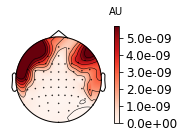

In [43]:
import numpy
freqs = numpy.arange(5., 100., 3.)
power = mne.time_frequency.tfr_morlet(
    passive_standard,
    freqs=freqs,
    n_cycles=freqs/2.,
    return_itc=False,
    average=False,
#    output='complex'
)
_ = power.average().plot_topomap(fmin=35., fmax=45.)


No baseline correction applied


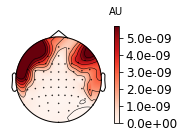

In [48]:
induced_power = power.average()
_ = induced_power.plot_topomap(fmin=35., fmax=45.)

No baseline correction applied


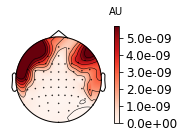

No baseline correction applied


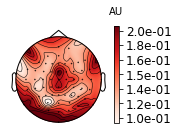

In [51]:
averaged_power, averaged_itc = mne.time_frequency.tfr_morlet(
    passive_standard,
    freqs=freqs,
    n_cycles=freqs/2.,
    return_itc=True,
    average=True,
#    output='complex'
)
_ = averaged_power.plot_topomap(fmin=35., fmax=45.)
_ = averaged_itc.plot_topomap(fmin=35., fmax=45., vmin=0.1, vmax=0.2)

In [ ]:
#TF_MAP
#itc
#evoked poewr 
#induced power
#save .npz  

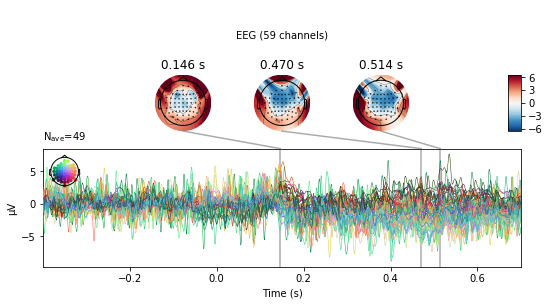

No baseline correction applied


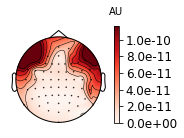

In [45]:
evoked_standard = passive_standard.average()
_ = evoked_standard.plot_joint()
evoked_power = mne.time_frequency.tfr_morlet(evoked_standard, freqs=freqs, n_cycles=freqs/2., return_itc=False)
_ = evoked_power.plot_topomap(fmin=35., fmax=45.)

No baseline correction applied


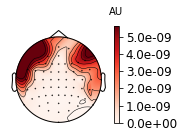

In [47]:
_ = (induced_power - evoked_power).plot_topomap(fmin=35., fmax=45.)